# Zero-noise extrapolation with gate folding and custom extrapolation
Zero-noise extrapolation (ZNE) is a technique for mitigating quantum noise in observable expectation value calculations. It works by executing a quantum circuit at increasing noise scales, taking expectation values with respect to those noise scales, and extrapolating to estimate a zero-noise expectation value. Both the noise amplification and extrapolation stages can be implemented in different ways. In this guide we amplify the noise with "digital gate folding", which means that two-qubit gates are replaced with equivalent sequences of the gate and its inverse. For example, replacing a unitary $U$ with $U U^† U$ would yield a noise amplification factor of 3. One can also implement amplification with probabilistic error amplification (PEA), which is covered in the [PEA guide](pea_with_noise_learning.ipynb). We extrapolate using a couple of built-in fitting strategies (linear and exponential), and we also demonstrate how to implement your own custom fitting function.

<img src="../images/zne.png" width="800"/>

The workflow will be as follows:
1. Specify a circuit and observable
2. Compute exact expectation values using Qiskit's statevector simulator
3. Compute noisy, unmitigated expectation values
4. Prepare a ZNE program with digital gate folding and sample circuits of varying noise scales
5. Extrapolate to the zero-noise limit with built-in and custom fitting functions
6. Compare the mitigated expectation values

### Define a problem and prepare a circuit

In this guide we will calculate the total magnetization of a Trotterized tranverse-field Ising model (TFIM) on ``8`` qubits in a ring topology. We will sweep several values of the strength of the transverse field and plot the magnetization as a function of the field strength. In a ring topology on an even number of qubits, the two-qubit gate layers can be split into 2 unique layers, as the red and green colors show in the coupling map below. Designing circuits to have a minimal set of unique entangling layers is important if one wants to learn a noise model, as the unique layers must be learned independently. If one has too many unique layers in their circuit, noise learning can become infeasible due to the sampling cost of learning many layers.

Edges of the same color may execute their gates simultaneously.


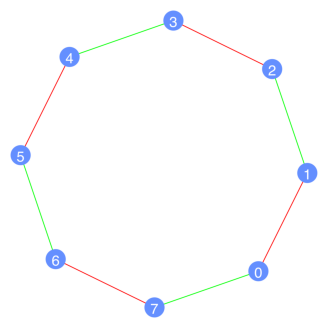

Visualization of 1 Trotter step


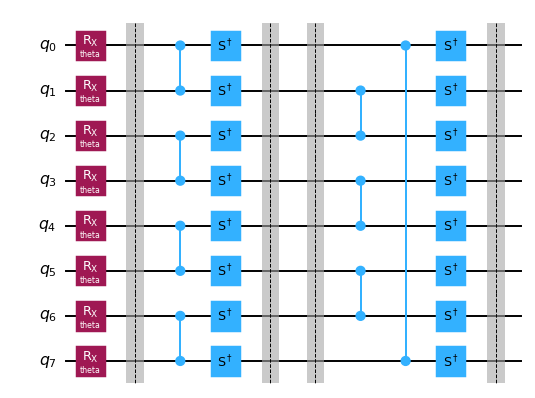

In [1]:
import warnings

import numpy as np
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.visualization import plot_coupling_map

warnings.filterwarnings("ignore")


def trotter_circuit(num_qubits, theta, layers, num_steps):
    """Trotterized transverse-field Ising evolution: RX on every site, then a CZ layer per coupling layer."""
    circuit = QuantumCircuit(num_qubits)
    for _ in range(num_steps):
        circuit.rx(theta, range(num_qubits))
        for layer in layers:
            circuit.barrier()
            for edge in layer:
                circuit.cz(*edge)
                circuit.sdg(edge)
            circuit.barrier()
    return circuit


num_qubits = 8
trotter_steps = 15
ring_coupling = [(i, (i + 1) % num_qubits) for i in range(num_qubits)]
layers = [ring_coupling[0::2], ring_coupling[1::2]]  # two disjoint layers of CZ gates
theta = Parameter("theta")
circuit = trotter_circuit(num_qubits, theta, layers, trotter_steps)

# Parameter values: theta in [0, 0.25 pi] - values for the transverse-field sweep
data_points = 6
parameter_values = np.linspace(0, 0.25 * np.pi, data_points).reshape((data_points, 1))

print("Edges of the same color may execute their gates simultaneously.")
display(
    plot_coupling_map(
        num_qubits=num_qubits,
        qubit_coordinates=None,
        coupling_map=ring_coupling,
        figsize=(4, 4),
        qubit_size=150,
        line_width=5,
        line_color=["red" if edge in layers[0] else "green" for edge in ring_coupling],
        font_size=90,
    )
)
print("Visualization of 1 Trotter step")
trotter_circuit(num_qubits, theta, layers, 1).draw("mpl", scale=0.7)

### Compute the exact expectation values classically

We use Qiskit's ``Statevector`` class to compute the exact expectation value of $Z_i$ on each site for every value of $\theta$.

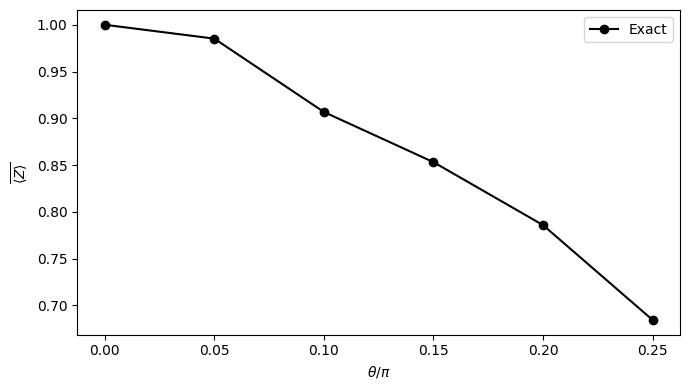

In [2]:
from qiskit.quantum_info import SparsePauliOp, Statevector

# Z on each site
observables = [SparsePauliOp("I" * (num_qubits - q - 1) + "Z" + "I" * q) for q in range(num_qubits)]

exact_evs = np.array(
    [
        [
            Statevector(circuit.assign_parameters([value])).expectation_value(obs).real
            for value in parameter_values.ravel()
        ]
        for obs in observables
    ]
)  # shape (observables, parameter values)

import matplotlib.pyplot as plt

x_vals = parameter_values.ravel() / np.pi
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_vals, exact_evs.mean(axis=0), "ko-", label="Exact")
ax.set_xlabel(r"$\theta/\pi$")
ax.set_ylabel(r"$\overline{\langle Z \rangle}$")
ax.legend()
plt.tight_layout()
plt.show()

### Perform a noisy, unmitigated expectation value calculation

A ``QuantumProgram`` contains a quantum circuit and a samplex in a format suitable for the Executor primitive. `MitigationTask.prepare` builds a ``QuantumProgram`` from the circuit, the observables and the parameter values, and boxes the circuit with the given boxing options. We set the ``measure_annotations`` boxing option to ``"change_basis"`` which rotates the measurements into the required bases, and we add ``add_tags: "unique_box"`` so the simulator can map a noise model onto the boxes of the circuit.

A user with QPU access would execute the program with an `Executor` built from a backend of the `QiskitRuntimeService`. Here we pass an `AerSimulator` to the `Executor`, which runs the program locally, and use its `layer_noise_model` simulator option to inject a random Pauli-Lindblad noise model on every layer of entangling gates, generated with `random_pauli_lindblad_noise` from `qiskit-mitigation` with an error per layered gate (EPLG) of ``0.003``, typical of current Heron QPUs.

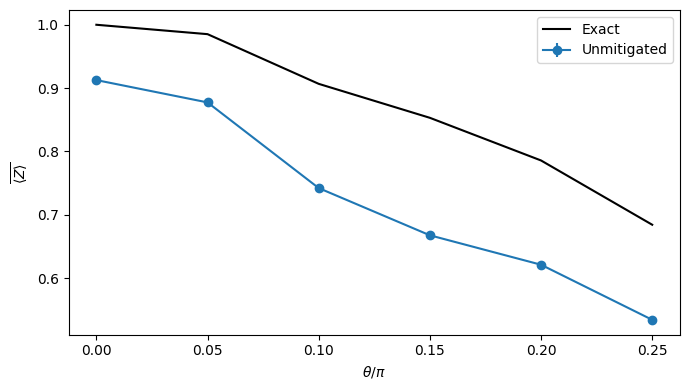

In [3]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Executor
from qiskit_mitigation import MitigationTask, find_combined_unique_layers
from qiskit_mitigation.noise import random_pauli_lindblad_noise

num_randomizations = 50
shots_per_randomization = 64

boxing_options = {"measure_annotations": "change_basis", "add_tags": "unique_box"}

# find the unique layers to generate the layered noise for
box_layers = find_combined_unique_layers([circuit], custom_boxing_options=boxing_options)
layer_noise_model = random_pauli_lindblad_noise(circuit, box_layers, eplg=0.003, seed=42)

# a local noisy simulator in place of a QPU backend
noisy_executor = Executor(
    AerSimulator(), options={"simulator": {"layer_noise_model": layer_noise_model}}
)

task = MitigationTask()
program = task.prepare(
    circuit=circuit,
    observables=observables,
    parameters=parameter_values,
    num_randomizations=num_randomizations,
    shots_per_randomization=shots_per_randomization,
    custom_boxing_options=boxing_options,
)
unmitigated_res = task.postprocess(noisy_executor.run(program).result())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_vals, exact_evs.mean(axis=0), "k-", label="Exact")
ax.errorbar(
    x_vals,
    np.mean(unmitigated_res.data.evs, axis=0),
    np.mean(unmitigated_res.data.stds, axis=0),
    fmt="o-",
    label="Unmitigated",
)
ax.set_xlabel(r"$\theta/\pi$")
ax.set_ylabel(r"$\overline{\langle Z \rangle}$")
ax.legend()
plt.tight_layout()
plt.show()

### Prepare a ZNE program with digital gate folding and execute it on the noisy simulator

Here we prepare a ZNE program containing circuits of increasing noise scales. Each noise factor represents the multiple of entangling gates that circuit contains (noise factor of ``3.0`` holds 3x more entangling gates than the original circuit). Below, we draw the first Trotter step of the twirled template with noise factor 1 and with noise factor 3 to visualize the amplification. For noise factor ``3.0``, every layer of the circuit is replaced by the layer, its inverse and the layer again.

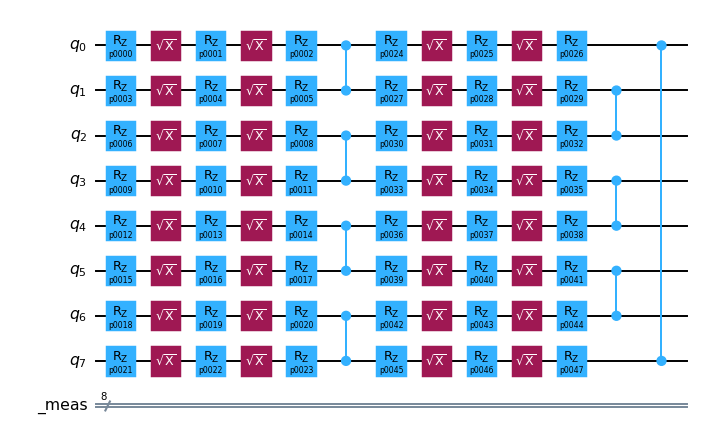

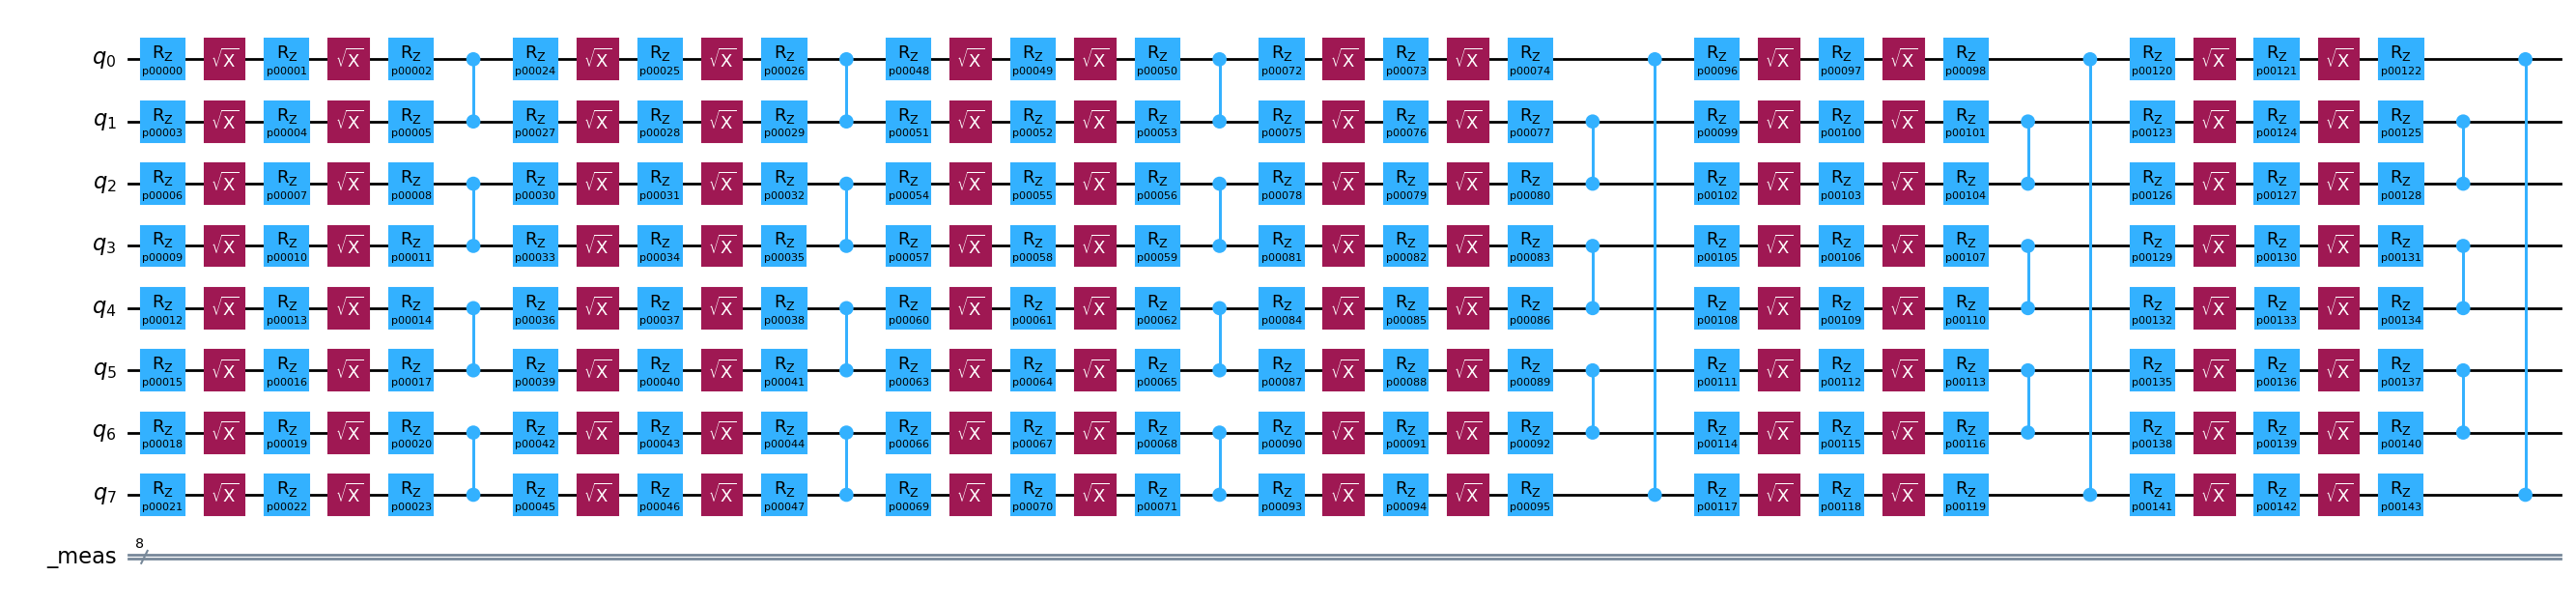

In [4]:
from qiskit_mitigation import ZNE

task_zne = ZNE()
program_zne = task_zne.prepare(
    circuit=circuit,
    observables=observables,
    parameters=parameter_values,
    num_randomizations=num_randomizations,
    shots_per_randomization=shots_per_randomization,
    custom_boxing_options=boxing_options,
    noise_factors=[1, 3, 5],  # ZNE option
)
job_zne_results = noisy_executor.run(program_zne).result()


def first_trotter_step(template, noise_factor):
    """The template up to the closing barrier of its first Trotter step (two layers, each folded ``noise_factor`` times)."""
    toy = template.copy_empty_like()
    for instruction in template.data:
        toy.append(instruction)
        if instruction.operation.name == "barrier" and instruction.operation.label.startswith(
            f"R{2 * noise_factor - 1}@"
        ):
            break
    return toy


display(
    first_trotter_step(program_zne.items[0].circuit, 1).draw("mpl", scale=0.7, plot_barriers=False)
)
first_trotter_step(program_zne.items[1].circuit, 3).draw("mpl", fold=-1, plot_barriers=False)

### Extrapolate to the zero-noise limit with built-in and custom fitting functions

Now that we have data for each noise scale, we can fit a function to the data and extrapolate back to the zero-noise value to estimate an expectation value of the noise-free observable. There are many ways to fit data, and the right choice of function depends on the nature of the data being sampled. ``MitigationTask.postprocess`` provides 3 built-in extrapolation functions -- ``linear``, ``exponential``, and ``double_exponential``. The `postprocess` method takes a list of extrapolation methods, evaluates them in order, and returns the first value with physically-valid values and finite variance. This means the order in which you specify the extrapolators has a big impact on which extrapolator is chosen. Submitting ``fallback`` as an extrapolator means if no valid answers were found, the circuit with the smallest noise factor will be chosen and returned. Under Pauli noise an observable decays exponentially with the noise factor, so with ``30`` layers (15 Trotter steps, 2 layers per step) of entangling gates the exponential extrapolator is the natural choice; we also extrapolate linearly, which is a common choice when the decay is small.

To use a custom fitting function, pass the `"custom"` extrapolator together with a `custom_fit` tuple containing the fitting function, a list with an initial guess for each of its parameters, and bounds. These are forwarded to ``scipy.optimize.curve_fit``. Post-processing can be repeated with different extrapolators without re-executing the program. Here we use a custom square-root fitting function. To visualize the extrapolation, we plot the site-averaged magnetization calculated at each noise factor for $\theta = 0.15\pi$, the three fits, and the site average of the extrapolated expectation values at the zero-noise point. The three data points look nearly linear, yet the linear extrapolation lands visibly below the exact value. As predicted, the exponential fit most-effectively estimates the noiseless expectation value.

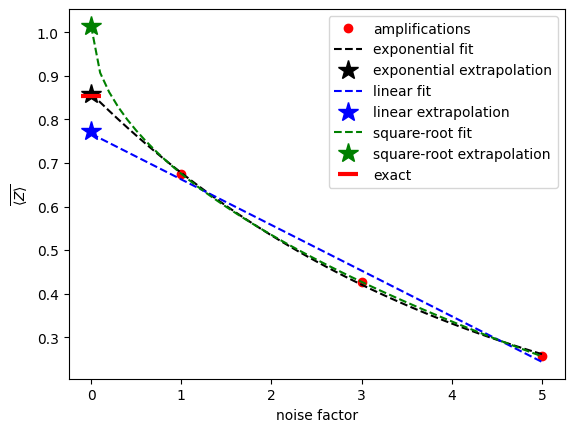

In [5]:
from scipy.optimize import curve_fit

zne_mitigated_exp = task_zne.postprocess(job_zne_results, extrapolator=["exponential", "linear"])
zne_mitigated_lin = task_zne.postprocess(job_zne_results, extrapolator=["linear"])


def sqrt_fit(x, a, b):
    return a * np.sqrt(x) + b


custom_fit = (sqrt_fit, [1.0, 1.0], (-np.inf, np.inf))
zne_mitigated_custom = task_zne.postprocess(
    job_zne_results, extrapolator=["custom", "exponential", "linear"], custom_fit=custom_fit
)

# The result holds the expectation value at each noise factor and the extrapolated value, but
# not the fit parameters, so we refit the same models here to draw the curves.
noise_factors = np.array([1, 3, 5])
angle = 3  # theta = 0.15 pi, the angle with the largest unmitigated error
amplifications = zne_mitigated_exp.data.evs_noise_factors[:, angle, :].mean(axis=0)
x_fit = np.linspace(0, 5, 51)
fits = {
    "exponential": (lambda x, a, b: a * np.exp(b * x), zne_mitigated_exp, "black"),
    "linear": (lambda x, a, b: a * x + b, zne_mitigated_lin, "blue"),
    "square-root": (sqrt_fit, zne_mitigated_custom, "green"),
}

plt.plot(noise_factors, amplifications, "o", color="red", label="amplifications")
for name, (fit, res, color) in fits.items():
    params, _ = curve_fit(fit, noise_factors, amplifications, p0=[1.0, -0.1])
    plt.plot(x_fit, fit(x_fit, *params), "--", color=color, label=f"{name} fit")
    plt.plot(
        [0],
        res.data.evs[:, angle].mean(),
        "*",
        color=color,
        markersize=15,
        label=f"{name} extrapolation",
    )
plt.plot(
    [0],
    exact_evs[:, angle].mean(),
    "_",
    color="red",
    markersize=15,
    markeredgewidth=3,
    label="exact",
)
plt.xlabel("noise factor")
plt.ylabel(r"$\overline{\langle Z \rangle}$")
plt.legend()
plt.show()

### Compare the mitigated expectation values

Here we plot the site-averaged magnetization of each method across the sweep across Ising rotation angles. Exponential extrapolation recovers the exact magnetization within its error bars, while linear extrapolation removes much of the bias but consistently undershoots, because the true decay is exponential. The square-root fit overshoots badly.

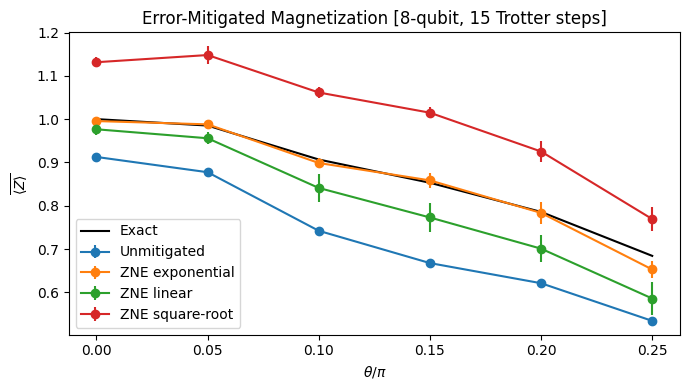

In [6]:
results = {
    "Unmitigated": unmitigated_res,
    "ZNE exponential": zne_mitigated_exp,
    "ZNE linear": zne_mitigated_lin,
    "ZNE square-root": zne_mitigated_custom,
}

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_vals, exact_evs.mean(axis=0), "k-", label="Exact")
for label, res in results.items():
    ax.errorbar(
        x_vals,
        np.mean(res.data.evs, axis=0),
        np.mean(res.data.stds, axis=0),
        fmt="o-",
        label=label,
    )
ax.set_xlabel(r"$\theta/\pi$")
ax.set_ylabel(r"$\overline{\langle Z \rangle}$")
ax.legend()
ax.set_title(f"Error-Mitigated Magnetization [{num_qubits}-qubit, {trotter_steps} Trotter steps]")
plt.tight_layout()
plt.show()